In [3]:
from base_model import train_kfold
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# XÂY DỰNG MÔ HÌNH (FINE-TUNING)
def build_model():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model, base_model


if __name__ == "__main__":

    results = train_kfold(build_model, preprocess_input, "MobileNetV2")

    # LẤY BEST FOLD
    best_idx = results["best_idx"]
    best_history = results["histories"][best_idx]
    best_test_gen = results["test_gens"][best_idx]

    print(f"\nBest Fold: {best_idx + 1}")

    # LOAD MODEL TỐT NHẤT
    best_model_path = f"saved_models/MobileNetV2_Fold_{best_idx+1}_best.keras"

    model, _ = build_model()
    model.load_weights(best_model_path)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print("Loaded best model!")

    best_test_gen.reset()

    pred_probs = model.predict(best_test_gen)
    pred_classes = (pred_probs > 0.5).astype(int).reshape(-1)

    true_classes = best_test_gen.classes
    class_names = list(best_test_gen.class_indices.keys())




TRAIN FOLD 1/5
Found 1876 images belonging to 2 classes.
Found 331 images belonging to 2 classes.
Found 552 images belonging to 2 classes.

PHASE 1: Train Head
Epoch 1/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.8526 - loss: 0.3323
Epoch 1: val_accuracy improved from None to 0.96677, saving model to saved_models\MobileNetV2_Fold_1_best.keras

Epoch 1: finished saving model to saved_models\MobileNetV2_Fold_1_best.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9046 - loss: 0.2358 - val_accuracy: 0.9668 - val_loss: 0.0906 - learning_rate: 0.0010
Epoch 2/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.9420 - loss: 0.1631
Epoch 2: val_accuracy did not improve from 0.96677
59/59 ━━━━━━━━━━━━━━━━━━━━ 50s 840ms/step - accuracy: 0.9568 - loss: 0.1159 - val_accuracy: 0.9154 - val_loss: 0.1913 - learning_rate: 0.0010
Epoch 3/15
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.9599 - loss: 0.1003
Epoch 3: val_accuracy did not improve from 0.96677
59/59 ━━

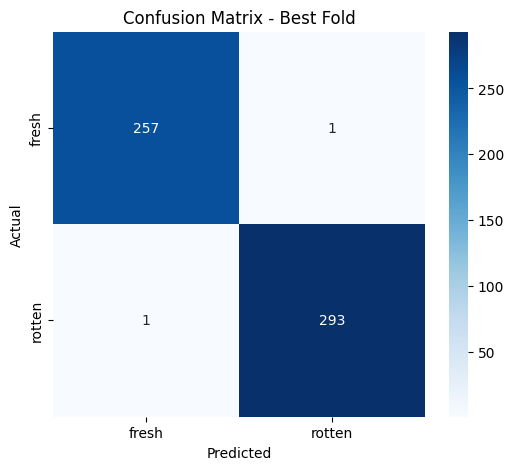

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Best Fold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Classification Report
print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(true_classes, pred_classes, target_names=class_names))


BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

       fresh       1.00      1.00      1.00       258
      rotten       1.00      1.00      1.00       294

    accuracy                           1.00       552
   macro avg       1.00      1.00      1.00       552
weighted avg       1.00      1.00      1.00       552



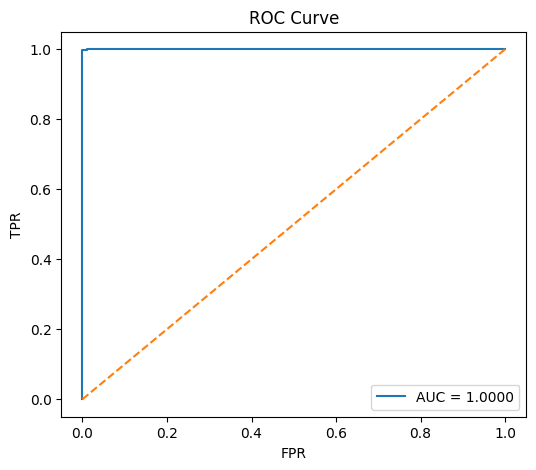

In [8]:
# ROC Curve
fpr, tpr, _ = roc_curve(true_classes, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()



Có 2 ảnh dự đoán sai


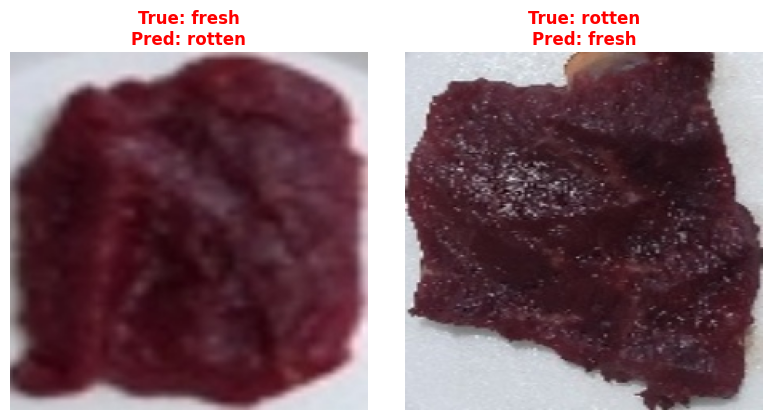

In [9]:
import numpy as np
# Ảnh Dự Đoán Sai
misclassified = np.where(pred_classes != true_classes)[0]

if len(misclassified) > 0:
    print(f"\nCó {len(misclassified)} ảnh dự đoán sai")

    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(misclassified[:6]):  # show 6 ảnh
        img_path = best_test_gen.filepaths[idx]
        img = plt.imread(img_path)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(
            f"True: {class_names[true_classes[idx]]}\nPred: {class_names[pred_classes[idx]]}",
            color='red', fontweight='bold'
        )
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("\nModel dự đoán đúng toàn bộ test set")

d:\App\python\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1164']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


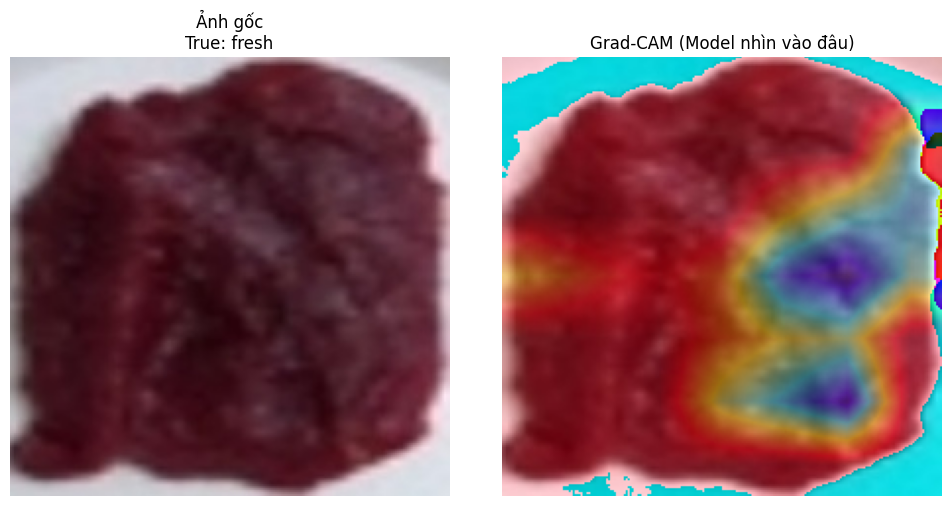

In [10]:
from tensorflow.keras.preprocessing import image
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)

    if max_val.numpy() == 0:
        return np.zeros_like(heatmap.numpy())

    heatmap /= max_val

    return heatmap.numpy()


# QUAN TRỌNG: MobileNetV2 dùng layer này
last_conv_layer_name = "Conv_1"

# chọn ảnh
target_idx = misclassified[0] if len(misclassified) > 0 else 0
img_path = best_test_gen.filepaths[target_idx]

# preprocess ảnh
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# dùng model (KHÔNG phải best_model nếu bạn đặt tên khác)
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# đọc ảnh gốc
img_orig = np.array(Image.open(img_path).convert("RGB"))

# resize heatmap
heatmap = cv2.resize(heatmap, (img_orig.shape[1], img_orig.shape[0]))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# overlay
superimposed_img = heatmap * 0.4 + img_orig
superimposed_img = np.uint8(superimposed_img)

# plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_orig)
plt.title(f"Ảnh gốc\nTrue: {class_names[true_classes[target_idx]]}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM (Model nhìn vào đâu)")
plt.axis('off')

plt.tight_layout()
plt.show()